# Check Guglielmo

In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys
if ".." not in sys.path: sys.path.append("..")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from monaqa2.data.plot_classical_query_vs_n import plot_classical_queries_vs_n
from monaqa2.data.classical_query import get_classical_query_stats, get_classical_query_fit

Partiamo dal numero di query

In [13]:
beta = 4.0
statistic = "median+mad"  # "mean+std", "mean+std-tail", or "median+mad"
eps = 1e-2                # 1e-{2,3,...,8}

# best classical and best quantum proposal 
PROPOSALS = ["uniform", "layden"]

proposal = "uniform"
table = get_classical_query_stats(proposal=proposal, a=np.inf, q0_mode="bhattacharyya", epsilon=eps, statistic=statistic)
classical_table = table[np.isclose(table["beta"].astype(float), float(beta)) & (table["count"].astype(int) >= 1)].copy()
A_c, b_c = get_classical_query_fit(proposal=proposal, a=np.inf, q0_mode="bhattacharyya", epsilon=eps, beta=beta, statistic=statistic, n_min=5, n_max=10)
print(f"Fit for the best MCMC classical move: {A_c:0.3f} * exp({b_c:0.3f} n)")

proposal = "layden"
table = get_classical_query_stats(proposal=proposal, a=np.inf, q0_mode="bhattacharyya", epsilon=eps, statistic=statistic)
quantum_table = table[np.isclose(table["beta"].astype(float), float(beta)) & (table["count"].astype(int) >= 1)].copy()
A_q, b_q = get_classical_query_fit(proposal=proposal, a=np.inf, q0_mode="bhattacharyya", epsilon=eps, beta=beta, statistic=statistic, n_min=5, n_max=10)
print(f"Fit for the best MCMC quantum move:  {A_q:0.3f} * exp({b_q:0.3f} n)")

Fit for the best MCMC classical move: 4.258 * exp(0.665) n
Fit for the best MCMC quantum move:   16.210 * exp(0.202) n


In [31]:
from scipy.optimize import brentq
from monaqa2.data.runtime_new import get_time_classical_walk_qemc, get_time_classical_walk_uniform

def f(n):
    num_classical_queries = A_c * np.exp(b_c * n)
    num_qemc_queries = A_q * np.exp(b_q * n)
    time_classical = get_time_classical_walk_uniform(n=20, num_classical_queries=num_classical_queries)
    time_quantum = get_time_classical_walk_qemc(n=20, num_classical_queries=num_qemc_queries, trotter_steps=50, logical_operation_time=1e-6)
    return time_classical - time_quantum

n_star = brentq(f, 1, 100)
print("The two lines for MCMC intercept at n=", n_star)

The two lines for MCMC intercept at n= 18.676341954306825


Sia $C(n) = 2.01 \times 10^{-9} n + 1.73 \times 10^{-9} n^2$ il tempo di una mossa classica e $Q(n) = 10^{-6} \times \text{depth}$ il tempo di una mossa quantum. Allora 

$$C(n) \times 4.258 \times \exp(0.665 n) = Q(n) \times 16.210 \times \exp(0.202 n)$$

che porta a 

$$\frac{Q(n)}{C(n)} = \frac{4.258}{16.210} \times \exp(0.463 n)$$

Per $n=18.68$ viene 

$$\frac{Q(n)}{C(n)} = 0.2627 \times 5677 = 1.498 \times 10^3$$

Mentre il valore che ci aspettavamo è:

$$\frac{10^{-6} \times [1 + 50 \times (1 + 18.68 + 1)]}{10^{-9} \times (2 \times 18.67 + 1.73 \times (18.67^2))}
= 10^3 \times \frac{1035}{640} = 1.617 \times 10^3$$

Dato $Q(n) = 1.6 \times 10^3 C(n)$ lo step quantum è $10^3$ volte più lento di quello classico. Sappiamo che
* $Q(20) = Q(\cdot) \approx 10^{-3} [s]$ tramite $10^{-6}$ secondi per operazione logica per circa $1000$ layer di rotazioni parallele per trotter;
* $C(20) = 10^{-9} \times 4.2 \times 10^2 \approx 5 \times 10^{-7} [s]$ tramite $10^{-9}n^2$ scaling dell'uniforme

Il ratio salta fuori come 
$$\frac{Q(20)}{C(20)} \approx 2 \times 10^{3}$$

(<Figure size 850x480 with 1 Axes>,
 <Axes: title={'center': 'Classical and logical-quantum runtime, beta=4.0, a=inf, q0=bhattacharyya, epsilon=0.01, Trotter=50'}, xlabel='$n$', ylabel='Runtime [s]'>)

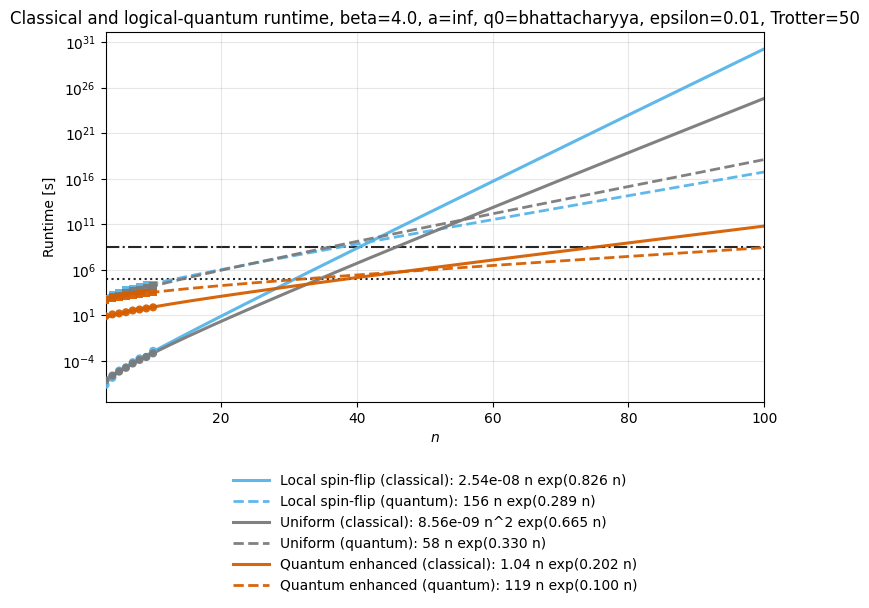

In [41]:
from monaqa2.data.plot_classical_logicalquantum_runtime_vs_n_quantum_walks_distance6 import plot_classical_logicalquantum_runtime_vs_n

plot_classical_logicalquantum_runtime_vs_n(
    beta=beta,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=eps,
    num_trotter_steps=50,
    logical_operation_time=1e-3,
    statistic=statistic,
)

In [45]:
get_time_classical_walk_uniform(n=1, num_classical_queries=1)

3.73178881248717e-09